## Week 3 Assignment - Unsupervised Learning.
Name : Sakshi Kiran Kekan

College : Sanjivani College of Engineering, Kopargaon.

Domain : Data Science.

# Week 3 Assignment
## Customer Intelligence / Country Segmentation using Unsupervised Learning

### Objective

The objective of this assignment is to perform customer intelligence and country segmentation using unsupervised machine learning techniques.

The workflow includes:

- Loading the dataset
- Cleaning and preprocessing data
- Scaling numerical features
- Finding the optimal number of clusters using the Elbow Method
- Applying K-Means clustering
- Comparing with DBSCAN clustering
- Visualizing clusters using PCA
- Generating meaningful insights from the clusters

In [1]:
!pip -q install pandas numpy matplotlib seaborn scikit-learn

## Import Required Libraries


In [2]:
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

sns.set(style="whitegrid")

pd.set_option("display.max_columns",100)
pd.set_option("display.max_rows",100)

## Load the Dataset

Upload the Country Data CSV file into Google Colab.

In [3]:
from google.colab import files
uploaded = files.upload()
csv_name = next(iter(uploaded))
df = pd.read_csv(io.BytesIO(uploaded[csv_name]))
df.head()

Saving Country-data.csv to Country-data.csv


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


## Dataset Verification

The dataset is verified by checking that all expected columns are present before preprocessing.

In [4]:
print(df.columns.tolist())

['country', 'child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']


## Data Cleaning and Preprocessing

Before applying clustering algorithms, the dataset needs to be cleaned and standardized.

The preprocessing steps include:

- Creating a copy of the original dataset
- Standardizing column names
- Removing duplicate records
- Converting feature columns into numeric data types
- Handling missing values using median imputation

These steps improve data quality and ensure the clustering algorithms produce reliable and meaningful results.

In [5]:
# Create a copy of the dataset
df = df.copy()

# Standardize column names
df.columns = [col.strip().lower() for col in df.columns]

# Remove duplicate rows
df = df.drop_duplicates()

# Convert all feature columns to numeric
for col in df.columns:
    if col != "country":
        df[col] = pd.to_numeric(df[col], errors="coerce")

# List of numeric columns
numeric_cols = [col for col in df.columns if col != "country"]

# Fill missing values using median
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# Check missing values
print("Missing Values:")
df.isnull().sum()

Missing Values:


,0
country,0
child_mort,0
exports,0
health,0
imports,0
income,0
inflation,0
life_expec,0
total_fer,0
gdpp,0


## Exploratory Data Analysis (EDA)

Exploratory Data Analysis helps understand the relationships among numerical features before clustering.

A correlation heatmap is generated to identify positive and negative correlations between country-level socio-economic indicators.

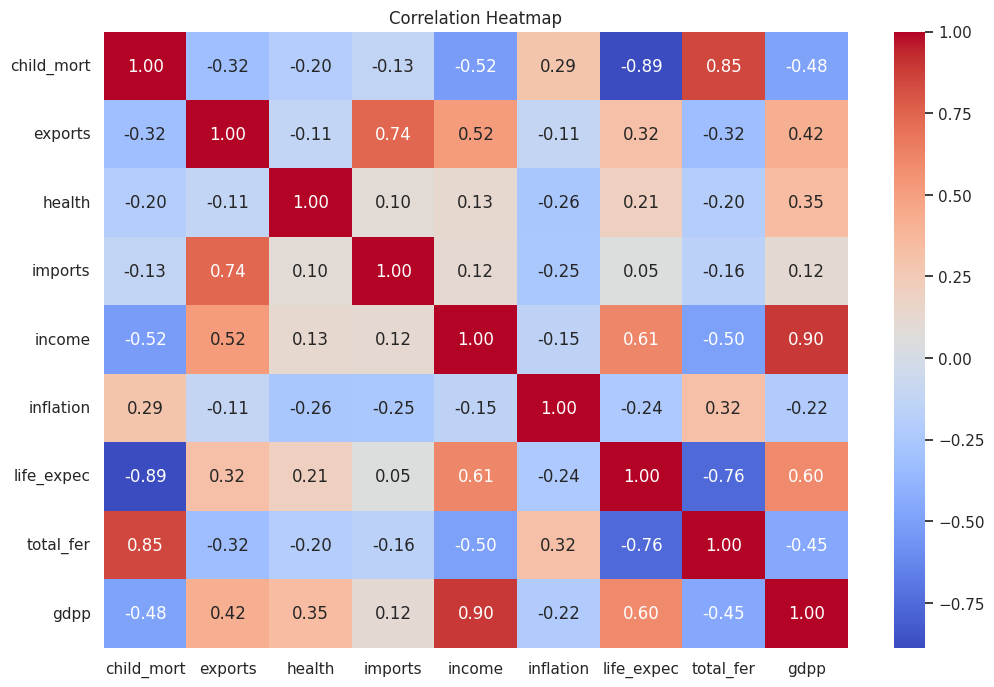

In [6]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

## Outlier Detection using Boxplots

Boxplots are used to visualize the distribution of each numerical feature and identify potential outliers.

Understanding outliers is important because clustering algorithms are sensitive to extreme values.

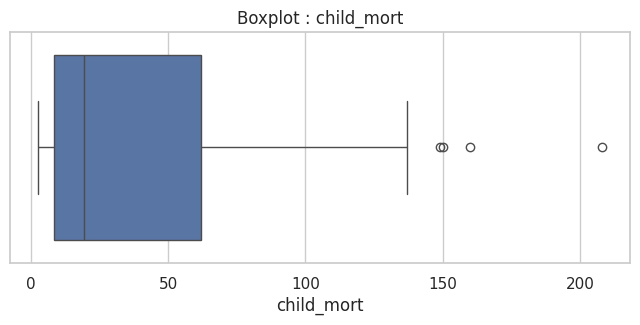

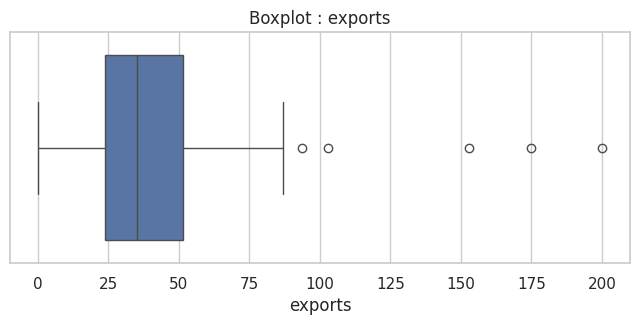

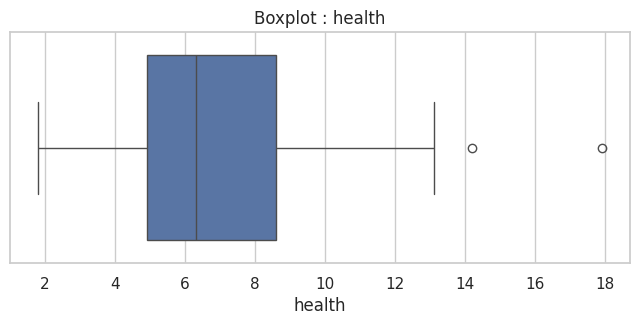

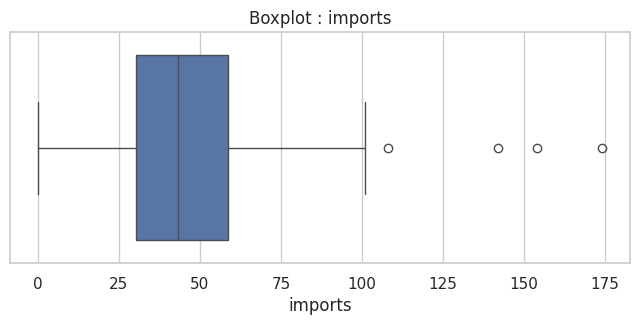

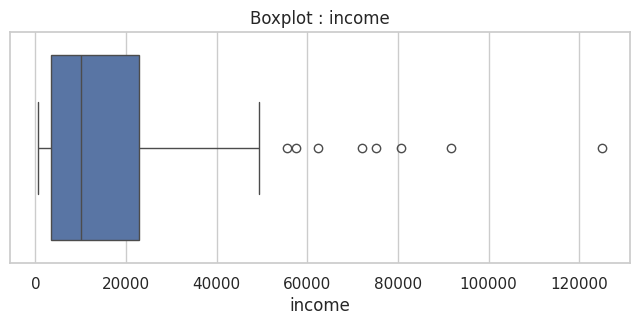

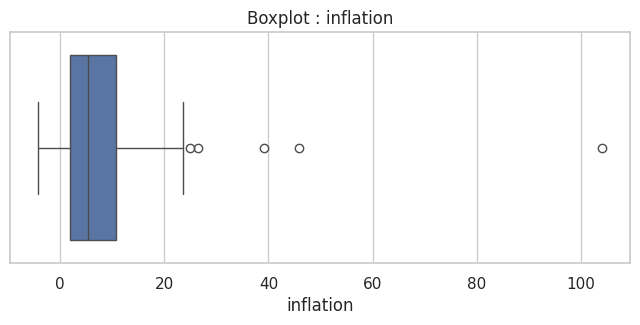

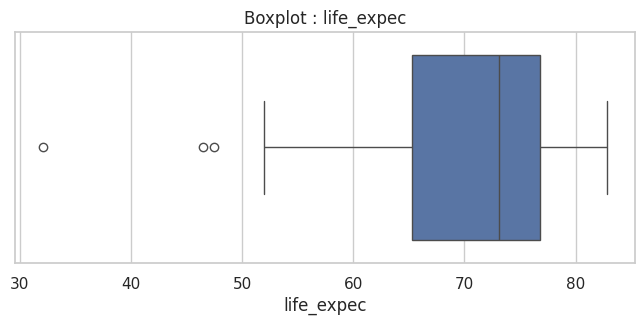

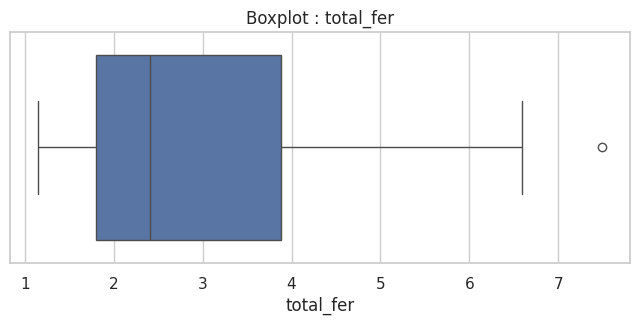

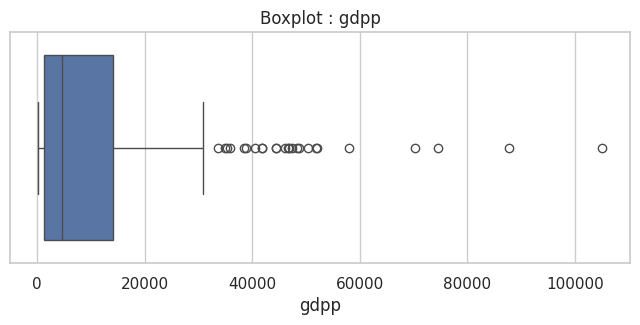

In [7]:
for col in numeric_cols:

    plt.figure(figsize=(8,3))

    sns.boxplot(x=df[col])

    plt.title(f"Boxplot : {col}")

    plt.show()

## Feature Scaling

Clustering algorithms calculate distances between observations.

Since the dataset contains features with different units and ranges (such as GDP, income, life expectancy, and inflation), feature scaling is essential.

StandardScaler transforms all numerical features so that they have a mean of zero and a standard deviation of one.

In [8]:
# Remove country column
features = df.drop(columns=["country"], errors="ignore")

# Initialize StandardScaler
scaler = StandardScaler()

# Scale the features
X_scaled = scaler.fit_transform(features)

print("Scaled Data Shape:", X_scaled.shape)

Scaled Data Shape: (167, 9)


## Determining the Optimal Number of Clusters using the Elbow Method

The Elbow Method evaluates K-Means models using different values of K.

For each value of K, the inertia (within-cluster sum of squares) is calculated.

The point where the inertia begins to decrease more slowly is considered the optimal number of clusters.

In [9]:
inertias = []

k_values = range(2,11)

for k in k_values:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)

    inertias.append(model.inertia_)

## Elbow Curve Visualization

The Elbow Curve visualizes the relationship between the number of clusters and inertia.

Based on the elbow point observed in the graph, the optimal number of clusters is selected for K-Means clustering.

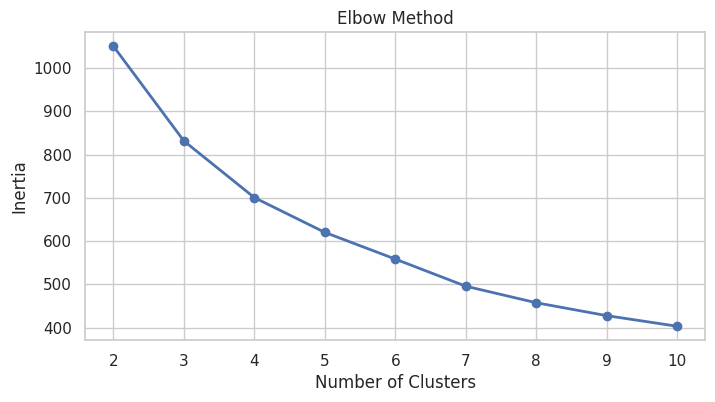

In [10]:
plt.figure(figsize=(8,4))

plt.plot(
    k_values,
    inertias,
    marker="o",
    linewidth=2
)

plt.xlabel("Number of Clusters")

plt.ylabel("Inertia")

plt.title("Elbow Method")

plt.grid(True)

plt.show()

## K-Means Clustering

Based on the Elbow Method, the optimal number of clusters is selected as **K = 3**.

The K-Means algorithm partitions the countries into three distinct groups based on their socio-economic indicators.

To evaluate the quality of clustering, the **Silhouette Score** is calculated. A higher silhouette score indicates better-defined and well-separated clusters.

In [11]:
# Define the optimal number of clusters
best_k = 3

# Train the K-Means model
kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

# Predict cluster labels
df["kmeans_cluster"] = kmeans.fit_predict(X_scaled)

# Calculate Silhouette Score
score = silhouette_score(
    X_scaled,
    df["kmeans_cluster"]
)

print(f"Silhouette Score: {score:.4f}")

# Display first few clustered countries
df[["country", "kmeans_cluster"]].head()

Silhouette Score: 0.2833


,country,kmeans_cluster
0,Afghanistan,1
1,Albania,2
2,Algeria,2
3,Angola,1
4,Antigua and Barbuda,2


## DBSCAN Clustering

In addition to K-Means, Density-Based Spatial Clustering of Applications with Noise (DBSCAN) is applied.

Unlike K-Means, DBSCAN identifies clusters based on density and can automatically detect noise or outlier points.

The clustering is performed using:

- eps = 1.5
- min_samples = 5

In [12]:
# Initialize DBSCAN
dbscan = DBSCAN(
    eps=1.5,
    min_samples=5
)

# Predict clusters
df["dbscan_cluster"] = dbscan.fit_predict(X_scaled)

print("DBSCAN Cluster Distribution:")
print(df["dbscan_cluster"].value_counts().sort_index())

DBSCAN Cluster Distribution:
dbscan_cluster
-1     30
 0    137
Name: count, dtype: int64


## Principal Component Analysis (PCA)

The original dataset contains multiple numerical features, making visualization difficult.

Principal Component Analysis (PCA) reduces the high-dimensional data into two principal components while preserving most of the variance.

These components are then used to visualize the K-Means clusters in two-dimensional space.

In [13]:
# Apply PCA
pca = PCA(
    n_components=2,
    random_state=42
)

X_pca = pca.fit_transform(X_scaled)

# Create visualization dataframe
viz = pd.DataFrame({
    "PCA 1": X_pca[:,0],
    "PCA 2": X_pca[:,1],
    "Cluster": df["kmeans_cluster"]
})

viz.head()

,PCA 1,PCA 2,Cluster
0,-2.913025,0.095621,1
1,0.429911,-0.588156,2
2,-0.285225,-0.455174,2
3,-2.932423,1.695555,1
4,1.033576,0.136659,2


## PCA Cluster Visualization

The scatter plot below visualizes the K-Means clustering results using the first two principal components.

Each color represents a different cluster, making it easier to observe how countries are grouped based on their socio-economic characteristics.

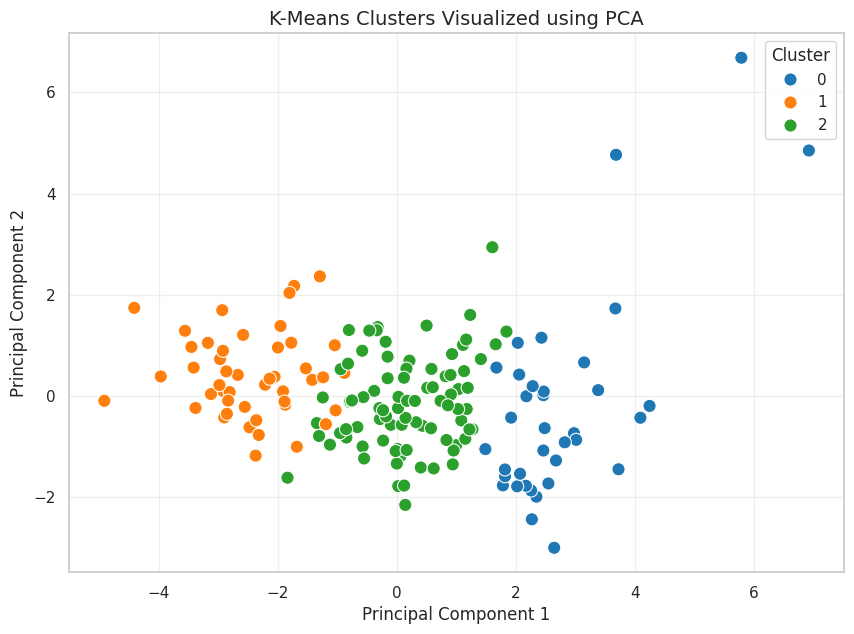

In [14]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    data=viz,
    x="PCA 1",
    y="PCA 2",
    hue="Cluster",
    palette="tab10",
    s=90
)

plt.title("K-Means Clusters Visualized using PCA", fontsize=14)

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.legend(title="Cluster")

plt.grid(alpha=0.3)

plt.show()

## Cluster Profiling

Cluster profiling summarizes the average socio-economic indicators for each cluster.

This helps identify the characteristics of each group, such as:

- Child mortality
- Income
- GDP per capita
- Life expectancy
- Fertility rate
- Healthcare expenditure

These statistics are used to derive meaningful business and development insights.

In [15]:
profile = (
    df.groupby("kmeans_cluster")[numeric_cols]
      .mean()
      .round(2)
)

print("Cluster Profile (Mean Feature Values):")
display(profile)

Cluster Profile (Mean Feature Values):


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
kmeans_cluster,,,,,,,,,
0,5.00,58.74,8.81,51.49,45672.22,2.67,80.13,1.75,42494.44
1,92.96,29.15,6.39,42.32,3942.40,12.02,59.19,5.01,1922.38
2,21.93,40.24,6.20,47.47,12305.60,7.60,72.81,2.31,6486.45


## Final Insights and Observations

The cluster profiling results provide meaningful insights into the socio-economic conditions of different groups of countries.

Based on the average values of child mortality, income, GDP per capita, life expectancy, fertility rate, and other indicators, the following observations can be made.

### Observation 1: High Child Mortality Cluster

Cluster **1** has the highest average child mortality rate (92.96), the lowest life expectancy (59.19 years), and the highest fertility rate (5.01). These indicators suggest that this cluster represents the least developed countries with limited healthcare access and challenging socio-economic conditions.

### Observation 2: High Income and GDP Cluster

Cluster **0** has the highest average income (45,672.22) and GDP per capita (42,494.44), along with the highest life expectancy (80.13 years) and the lowest child mortality rate (5.00). This cluster represents economically developed countries with better healthcare systems and higher standards of living.

### Observation 3: Moderately Developed Countries

Cluster **2** represents moderately developed countries. It shows moderate income (12,305.60), GDP per capita (6,486.45), child mortality (21.93), and life expectancy (72.81 years). These countries are generally developing and demonstrate balanced socio-economic performance.

### Observation 4: Countries Requiring Developmental Support

Countries belonging to **Cluster 1** should be prioritized for international aid and policy intervention. Investments in healthcare, education, nutrition, and economic development could significantly improve living standards and reduce child mortality.

### Observation 5: Overall Clustering Insight

The clustering analysis clearly demonstrates that countries with higher income and GDP per capita generally exhibit lower child mortality, lower fertility rates, and higher life expectancy. This highlights the strong relationship between economic development and quality of life.